In [1]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from collections import OrderedDict
import matplotlib.pyplot as plt

# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

root_dir  = Path("chest_xray")
train_dir = root_dir / "train"   # NORMAL, bacteria, virus
test_dir  = root_dir / "test"    # NORMAL, bacteria, virus

AUTOTUNE = tf.data.AUTOTUNE

2025-12-11 18:23:13.804871: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [3]:

# Load full training (unbatched) and test
train_full = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,          # unbatched
)

# Unbatched test set
test_raw = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,          # unbatched
)

class_names = train_full.class_names   # ['NORMAL', 'bacteria', 'virus']
print("3-class classes:", class_names)


Found 5232 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
3‑class classes: ['NORMAL', 'PNEUMONIA']


2025-12-11 18:23:16.865061: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 18:23:16.956113: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:83:00.0, compute capability: 7.0


In [4]:
total_train = train_full.cardinality().numpy()
val_size    = int(0.10 * total_train)
train_size  = total_train - val_size

train_raw = train_full.take(train_size)
val_raw   = train_full.skip(train_size)

print("train_size:", train_size, "val_size:", val_size)


# --- subsets from train_raw ---
total_train = train_raw.cardinality().numpy()

def make_subset_B(fraction):
    n = int(total_train * fraction)
    subset_raw = train_raw.take(n)
    return prepare(subset_raw, shuffle=True, repeat=False)

train_10  = make_subset_B(0.10)
train_25  = make_subset_B(0.25)
train_50  = make_subset_B(0.50)
train_100 = prepare(train_raw, shuffle=True, repeat=False)

val  = prepare(val_raw,  shuffle=False, repeat=False)
test = prepare(test_raw, shuffle=False, repeat=False)

# sanity check on test shapes
for xb, yb in test.take(1):
    print("test batch shapes:", xb.shape, yb.shape)

train_size: 4709 val_size: 523
test batch shapes: (32, 224, 224, 3) (32,)


In [5]:
def make_backbone_B():
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",   
        pooling=None        
    )

def make_classifier_B():
    backbone = make_backbone_B()
    backbone.trainable = False   # frozen for B2‑style experiments

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation="softmax")(x)  # 3 classes

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [6]:
EPOCHS = 20
b_subsets = {
    "10%": train_10,
    "25%": train_25,
    "50%": train_50,
    "100%": train_100,
}

histories_B = {}
tests_B     = {}
models_B    = OrderedDict()

for name, train_ds in b_subsets.items():
    print(f"\n=== B (MobileNetV2 transfer) training on {name} of pool ===")
    model = make_classifier_B()
    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val,
    )

    histories_B[name] = history.history
    tests_B[name]     = model.evaluate(test, return_dict=True)
    models_B[name]    = model

print("B 3‑class test metrics per subset:", tests_B)




=== B (MobileNetV2 transfer) training on 10% of pool ===
Epoch 1/20


2025-12-11 18:23:25.457641: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2025-12-11 18:23:26.436551: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x55e4cd8379c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-11 18:23:26.436584: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-12-11 18:23:26.441816: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-11 18:23:26.543731: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


15/15 [==============================] - 16s 740ms/step - loss: 0.8233 - accuracy: 0.6553 - val_loss: 0.3856 - val_accuracy: 0.8011
Epoch 2/20
15/15 [==============================] - 12s 651ms/step - loss: 0.4641 - accuracy: 0.8021 - val_loss: 0.2947 - val_accuracy: 0.8834
Epoch 3/20
15/15 [==============================] - 12s 670ms/step - loss: 0.3687 - accuracy: 0.8191 - val_loss: 0.2313 - val_accuracy: 0.9101
Epoch 4/20
15/15 [==============================] - 12s 672ms/step - loss: 0.2614 - accuracy: 0.8851 - val_loss: 0.2099 - val_accuracy: 0.9273
Epoch 5/20
15/15 [==============================] - 12s 664ms/step - loss: 0.2570 - accuracy: 0.8787 - val_loss: 0.1866 - val_accuracy: 0.9465
Epoch 6/20
15/15 [==============================] - 12s 658ms/step - loss: 0.2131 - accuracy: 0.9277 - val_loss: 0.1712 - val_accuracy: 0.9388
Epoch 7/20
15/15 [==============================] - 12s 665ms/step - loss: 0.2179 - accuracy: 0.9170 - val_loss: 0.1667 - val_accuracy: 0.9312
Epoch 8/20

74/74 [==============================] - 15s 158ms/step - loss: 0.0620 - accuracy: 0.9796 - val_loss: 0.0859 - val_accuracy: 0.9694
Epoch 17/20
74/74 [==============================] - 15s 160ms/step - loss: 0.0608 - accuracy: 0.9771 - val_loss: 0.0971 - val_accuracy: 0.9656
Epoch 18/20
74/74 [==============================] - 15s 160ms/step - loss: 0.0586 - accuracy: 0.9817 - val_loss: 0.0593 - val_accuracy: 0.9790
Epoch 19/20
74/74 [==============================] - 16s 163ms/step - loss: 0.0584 - accuracy: 0.9792 - val_loss: 0.0836 - val_accuracy: 0.9694
Epoch 20/20
20/20 [==============================] - 1s 44ms/step - loss: 0.2580 - accuracy: 0.9071

=== B (MobileNetV2 transfer) training on 100% of pool ===
Epoch 1/20
148/148 [==============================] - 21s 105ms/step - loss: 0.3638 - accuracy: 0.8480 - val_loss: 0.1593 - val_accuracy: 0.9446
Epoch 2/20
148/148 [==============================] - 19s 103ms/step - loss: 0.1562 - accuracy: 0.9444 - val_loss: 0.1241 - val_accu

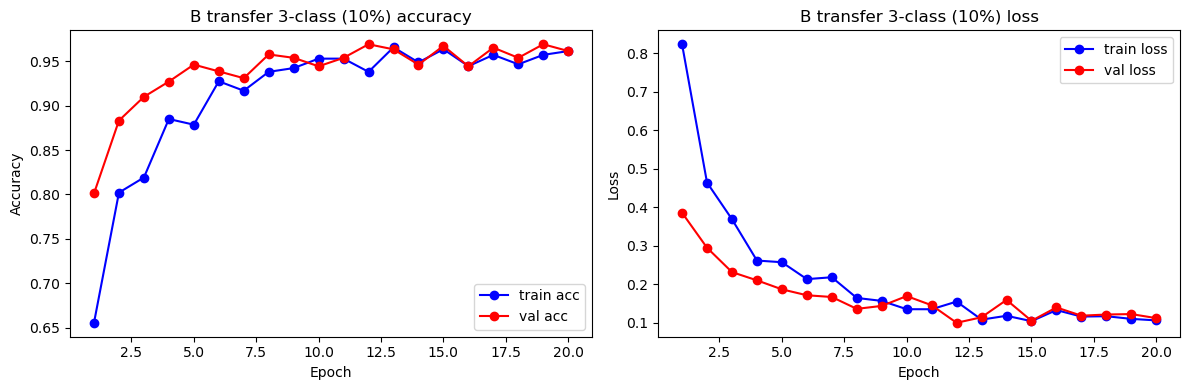

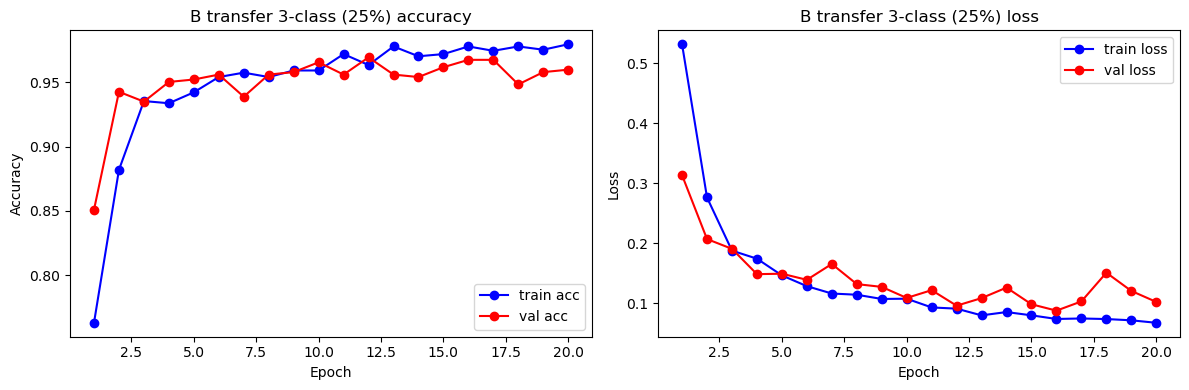

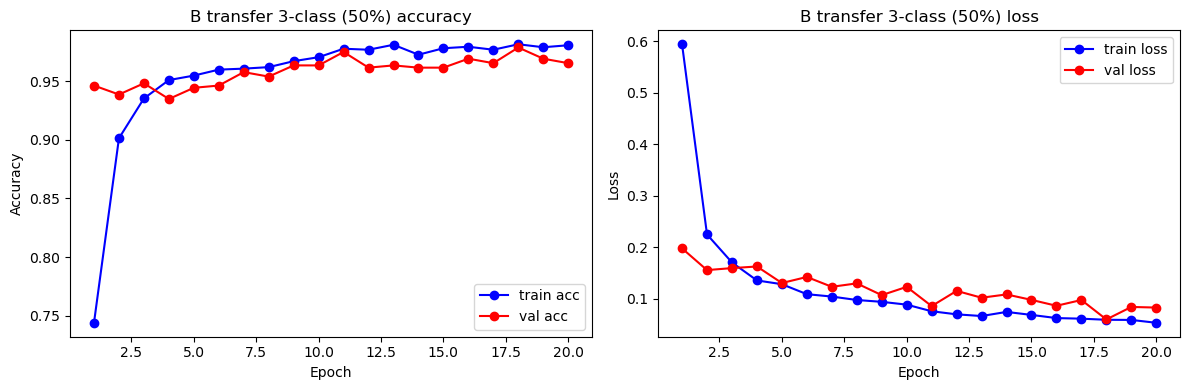

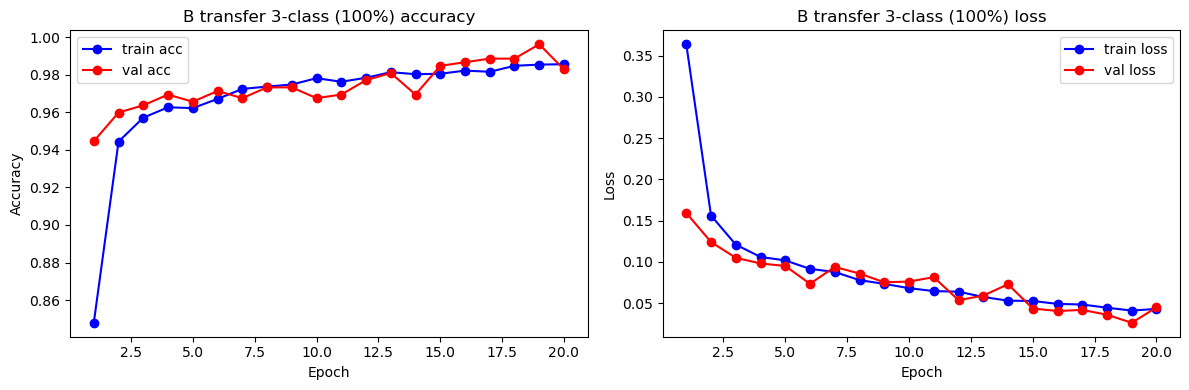

In [7]:
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

def plot_history(history, title_prefix="Model"):
    acc     = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss    = history.history.get("loss", [])
    val_loss= history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if len(acc) > 0:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if len(val_acc) > 0:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if len(loss) > 0:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if len(val_loss) > 0:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    
for frac, hist_dict in histories_B.items():
    plot_history(HistoryWrapper(hist_dict),
                 title_prefix=f"B transfer 3‑class ({frac})")


In [8]:
from sklearn.metrics import classification_report, confusion_matrix


# true labels from unbatched test_raw
y_true_batches = []
for _, labels in test_raw:
    y_true_batches.append(labels.numpy().ravel())
y_true = np.concatenate(y_true_batches, axis=0)
print("y_true shape:", y_true.shape)

for name, model in models_B.items():
    print(f"\n=== B 3‑class test report – subset {name} ===")
    probs  = model.predict(test)
    y_pred = probs.argmax(axis=1)

    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    print("Confusion matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

y_true shape: (624,)

=== B 3‑class test report – subset 10% ===
20/20 [==============================] - 1s 44ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.74      0.84       234
   PNEUMONIA       0.86      0.99      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.86      0.88       624
weighted avg       0.91      0.90      0.89       624

Confusion matrix:
[[173  61]
 [  4 386]]

=== B 3‑class test report – subset 25% ===
20/20 [==============================] - 1s 43ms/step
Classification report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.74      0.84       234
   PNEUMONIA       0.86      0.99      0.92       390

    accuracy                           0.90       624
   macro avg       0.92      0.86      0.88       624
weighted avg       0.91      0.90      0.89       624

Confusion matrix:
[[172  62]
 [  3 387]]

